# Machine Problem: Automatic Differentiation

Automatic Differentiation is at the heart of the most popular Deep Learning Frameworks like PyTorch and Jax. This allows us to define custom methods as a composite of operations, and autograd can automatically differentiate through these methods. 

In this Machine Problem we will be building a fully functional Autograd system to train a simple Multilayer Perceptron model for classification of MNIST digits.

## Instructions

The first thing you need to do is to download this file: mp05.zip. It has the following content:

- ```submitted.py```: Your homework. Edit, and then submit to [Gradescope](https://www.gradescope.com/login).
 
- ```mp05_notebook.ipynb```: This is a Jupyter notebook to help you debug. You can completely ignore it if you want, although you might find that it gives you useful instructions.
  
- ```grade.py```: Once your homework seems to be working, you can test it by typing python grade.py, which will run the tests in tests/tests_visible.py.

- ```tests/test_visible.py:``` This file contains about half of the unit tests that Gradescope will run in order to grade your homework. If you can get a perfect score on these tests, then you should also get a perfect score on the additional hidden tests that Gradescope uses.

- ```data```: This directory contains the MNIST training data

- ```load_mnist.py```: This file has a helper method to load the dataset

- ```requirements.txt```: This tells you which python packages you need to have installed, in order to run ```grade.py```. You can install all of those packages by typing ```pip install -r requirements.txt``` or ```pip3 install -r requirements.txt```.

This file ```(mp05_notebook.ipynb)``` will walk you through the whole MP, giving you instructions and debugging tips as you go.

### About ```submitted.py```

Inside ```submitted.py``` some methods are already provided to you! They are indicated that you should change nothing.

For the following methods, you should not change anything:

- ```ensure_tensor```
- ```Tensor```
- ```add``` (Use this as an example for the other methods)

You will be solving the following methods:
- ```broadcast_grad_accumulate```
- ```sub```
- ```mul```
- ```div```
- ```matmul```
- ```log```
- ```exp```
- ```sum```
- ```max```
- ```backward```

After you solve all of the above, the training code to build a Multilayer perceptron on MNIST data is provided for you!

### Import Dependencies

All we need is Numpy!

In [7]:
!pip install -q numpy matplotlib

import submitted
import importlib
import numpy as np
import matplotlib.pyplot as plt

### Backpropagation 

Neural Networks are just a stack of operations, some of which contain learnable parameters. Our goal is to minimize some loss function w.r.t these learnable parameters. Thus we need to compute the derivaitve
of our loss w.r.t these parameters so we can perform gradient descent.

### Case Study: Sigmoid

The sigmoid function is a common method used in Deep Learning to convert raw outputs to probabilities.

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

And its derivative is easily derived as:

$$\frac{d\sigma(x)}{dc} = \sigma(x) (1 - \sigma(x))$$

Lets pretend that you dont know the derivative, can we compute it differently? How can we compute the derivative of a function without explicity computing its derivative?

We can first write the sigmoid function as a compose of simpler ones like:

$$
a = -1 \cdot x
$$

$$
b = e^{a}
$$

$$
c = 1 + b
$$

$$
\sigma(x) = \frac{1}{c}
$$

What we want is the derivative of the output $ \sigma(x) $ w.r.t the input $x$, so using standard chain rule:

$$\frac{d\sigma(x)}{dx} = \frac{d\sigma(x)}{dc}\frac{dc}{db}\frac{db}{da}\frac{da}{dx}$$

And each of these derivatives are expressed as:

- $\frac{d\sigma(x)}{dc}$ - Derivative of Division
- $\frac{dc}{db}$ - Derivative of Sum
- $\frac{db}{da}$ - Derivative of Exponentiation
- $\frac{da}{dx}$ - Derivative of Multiplication

So if we can describe these sub operations and their derivatives, then we can chain together their derivatives to get the final derivative automatically. TLDR: Without explicitly defining the derivative of a sigmoid, we can compute the derivative of the smaller operations happening and chain them together!

### Python Recap \#1: Closures

We will be using function closures to define our methods. A closure is essentially a function that remembers and has access to variables from its enclosing (outer) scope, even after that outer function has finished executing.

Here is an example:

We will create a function called ```create_function``` that takes in a value ```what_to_add```. The inner function ```add``` uses this, and this is remembered even after the ```create_function``` is done executing

For more details just take a [look here](https://realpython.com/python-closure/) to understand python variable captures:



In [8]:
def create_function(what_to_add):
  """
  This method returns another method called ```add```. The inner method ```add```
  uses the variable ```what_to_add``` from the outer scope and is remembered
  at execution time of the returned method. This is called a closure.
  """
  def add(x):
      return x + what_to_add  # what_to_add is "remembered" in the closure
  return add

### Create the adding function ###
adding_function = create_function(5)
print(adding_function)

### Run the adding function (adding 5 from the closure to 10) ###
print(adding_function(10))

<function create_function.<locals>.add at 0x7cce39c98e00>
15


### Python Recap #2: Dunder Methods

In Python, dunder methods (short for double underscore) are special methods that let your objects interact with Python’s built-in syntax and operators.

There are a lot of these but we will mainly be focusing on math operations like sum, multiply, etc...

Lets see how python defines these for things like ```integers```

```python
# The type of the number 2 is int
print(type(2)) -> <class 'int'>

# Add together two integers
print(2 + 3)

# Equivalently we can do
(2).__add__(3)
```

This works because the integer class has the dunder method \_\_add\_\_
which is triggered by the ```+``` operation. And within this dunder method the actual logic for adding is contained.



In [9]:
# The type of the number 2 is int
print(type(2))

# Add together two integers
print(2 + 3)

# Equivalently we can do
(2).__add__(3)

<class 'int'>
5


5

## Tensor

The core part of our Autograd system will be the Tensor class. The Tensor is a wrapper on Numpy arrays that can also track the computational graph to backpropagate on. This means each tensor can do the following:

1. Store the Parents of an operation
2. Store the backward method needed for gradient computation
3. Perform backpropagation using Topological Sort

### What operations do we need?

#### Linear Layers
$$ y = xW + b $$

- matrix multiplication
- Addition (adding two different tensors together)

### Tanh Activation
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

- exponentiation
- multiplication
- division

#### Stable Softmax
$$\text{softmax}(x_i) = \frac{e^{x_i - \max_j x_j}}{\sum_{k=1}^{n} e^{x_k - \max_j x_j}}$$

- exponentiation
- sum (reducing along a dimension of a tensor)
- division
- max (along a dimension of a tensor)

#### Cross Entropy Loss

$$L = -1 * \sum_i y_i \log(p_i)$$

- log
- sum (reducing along a dimension of a tensor)
- multiplication

## Types of Operations

Operations can be generally grouped into 3 categories:

- Binary Operations (between two tensors like A + B)
- Unary Operations (on a single tensor like log(A))
- Reduction Operations (like the sum of a tensor that reduced dimensionality)

**Binary Operations**:
- Add
- Sub
- Mul
- Div
- Matmul

**Unary Operations**
- Exp
- Log

**Reduction Operations**
- Sum
- Max

### A Short Example

We define a Tensor here with only the ```__add__```  operation. The more complete example we will actually be working with is in the ```submitted.py```. 

In [10]:
import numpy as np

def ensure_tensor(x):
    """
    
    #### DO NOT CHANGE ####
    
    Quick helper method to check if something is a tensor
    otherwise convert it. Tensors have a .grad attribute
    unlike Numpy so wwe can check for that!
    """
    if hasattr(x, "grad"):
        return x
    else:
        return Tensor(x, requires_grad=False)
        
class Tensor:

    """
    This is the structure for a tensor! There is no need 
    to change any code here, through the MP we will be defining 
    all of these methods!

    Args:
        - array: numpy array
        - requires_grad: do we need to track gradients on this tensor
        - parents: From what tensor was this new tensor derived from
        - backward_fn: What is the backward method for this operation
    """
    def __init__(self,
                 array,
                 requires_grad=False,
                 parents=(),
                 grad_fn=None,
                 grad_fn_name=None):

        self.array = np.array(array, dtype=float)
        self.requires_grad = requires_grad
        self.grad = np.zeros_like(self.array) if requires_grad else None
        self.parents = parents
        self.grad_fn = grad_fn
        self.grad_fn_name = grad_fn_name

    def zero_grad(self):
        """
        Allows us to zero out the gradients. After an optimization step, we can use this
        to zero the grad for the next gradient computation
        """
        if self.requires_grad:
            self.grad = np.zeros_like(self.grad)

    @property
    def shape(self):
        """
        Allows us to do Tensor.shape to get the shape, just like in numpy where you can
        do ndarray.shape to get the shape of the array
        """
        return self.array.shape
        
    def __add__(self, other):
        """
        self + other
        """
        return add(ensure_tensor(self), ensure_tensor(other))

    def __radd__(self, other):
        """
        __r(op)__ is a reverse method incase of failure. For example, if we do:

            Tensor + Int -> (Tensor).__add__(Int) This will work as our Tensor class has a __add__ method that can handle this by converting the int
            to a Tensor first and then performing the operation (this will be defined in our add() method later

            Int + Tensor -> (Int).__add__(Tensor) This will fail, as the default Python Int doesnt know how to perform an add operation with a Tensor
            as the Tensor is a class we are making and Python Int has never seen this before. This then triggers Python to try __radd__ which will
            be again Tensor + Int -> (Tensor).__add__(Int) as a backup case to see if this works.

        self + other
        """
        return add(ensure_tensor(self), ensure_tensor(other))

    def __repr__(self):

        """
        Just some pretty printing to make it easier to inspect the Tensors!
        """
        data = self.array

        data_str = np.array2string(
            data,
            separator=" ",
            precision=3,
            floatmode="fixed",
            max_line_width=80
        )

        lines = data_str.split("\n")
        if len(lines) > 1:
            indent = " " * len("tensor(")
            data_str = lines[0] + "\n" + "\n".join(indent + line for line in lines[1:])

        grad_info = ""
        if getattr(self, "requires_grad", False):
            if getattr(self, "grad_fn_name", None) is not None:
                grad_info = f", grad_fn={getattr(self, 'grad_fn_name', None)}"
            else:
                grad_info = ", requires_grad=True"
                
        return f"tensor({data_str}{grad_info})"




### Lets Do An Example 

We will provide how to do the ```add``` method so you can understand the structure of how to write these methods
and things we need to account for like broadcasting!

#### Recap: Broadcasting

Broadcasting is commonly found in most array processing packages like Numpy. The idea is to repeatedly add lower dimensional tensors
to higher dimensional ones. For example

$$
\begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} + 
\begin{bmatrix}10 & 20 & 30\end{bmatrix} = 
\begin{bmatrix}11 & 22 & 33 \\ 14 & 25 & 36\end{bmatrix}
$$

So in numpy if we try to add together a ```(2 x 3)``` tensor with a ```(3)``` vector, it will automatically broadcast over the first dimension, essentially
just repeating along the dimension like so:

$$
\begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} + 
\begin{bmatrix}10 & 20 & 30 \\ 10 & 20 & 30\end{bmatrix} = 
\begin{bmatrix}11 & 22 & 33 \\ 14 & 25 & 36\end{bmatrix}
$$

This can be a little challenging as tensors have different number of dimensions. To simplify, we will always ensure that tensors we want to do any binary operations
between have the same number of dimensions, but the dimensions we want to broadcast over is clearly indicated with 1. So instead of doing a ```(2 x 3)``` tensor with a ```(3)``` vector, 
we will instead do ```(2 x 3)``` tensor with a ```(1 x 3)``` tensor, and the ```1``` will be the dimension that we broadcast over if needed!

#### Add Method

We will first implement the sum of two tensors (accounting for potential broadcasting). Lets say we have some operation as:

$$ y = A + B$$

We want the derivative of the output w.r.t the different inputs:

$$\frac{dy}{dA}, \frac{dy}{dB}$$

Well thats pretty easy:

$$\frac{dy}{dA} = 1, \frac{dy}{dB} = 1$$

But what we really want isnt just deriviatve of $y$ w.r.t to these variables, but rather the derivative of the loss $L$ w.r.t these variables. This assumes that we already
have our $\frac{dL}{dy}$ which is our upstream gradients on our computational graph. Then all we need is:

$$\frac{dL}{dA}=\frac{dL}{dy}\frac{dy}{dA}=\frac{dL}{dy}*1, \frac{dL}{dB}=\frac{dL}{dy}\frac{dy}{dB}=\frac{dL}{dy}*1$$

#### Adjusting for Broadcasting

The upstream gradients are always in the shape of our output tensor. So lets pretend $A$ and $B$ are learnable parameters we are computing gradients for and in our forward method we did:

$$
y = A + B = \begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} + 
\begin{bmatrix}10 & 20 & 30\end{bmatrix} = 
\begin{bmatrix}11 & 22 & 33 \\ 14 & 25 & 36\end{bmatrix}
$$

In our backward method, the upstream grad would be in the shape of our output ```(2x3)```

$$\frac{dL}{dy} = \begin{bmatrix}\nabla_0 & \nabla_1 & \nabla_2\\ \nabla_3 & \nabla_4 & \nabla_5\end{bmatrix}$$

#### Grad w.r.t A
So following our gradient rule for add we have for $A$:

$$\frac{dL}{dA} =
\frac{dL}{dy}\frac{dy}{dA}=
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}
\frac{dy}{dA} =
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix} \cdot 1=
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}$$

And so we have our gradients as a ```(2 x 3)``` tensor and our actual parameters $A$ is also ```(2 x 3)```. Thus we can easily do gradient descent. 

$$
A \leftarrow A - \lambda \cdot \begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix} = \begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} - \lambda \cdot \begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}
$$

And so we have our gradients as a ```(2 x 3)``` tensor and our actual parameters $A$ is also ```(2 x 3)```. Thus we can easily do gradient descent. 

#### Grad w.r.t B

What about for $B$? Following the same logic we get:

$$\frac{dL}{dB} =
\frac{dL}{dy}\frac{dy}{dB}=
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}
\frac{dy}{dB} =
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix} \cdot 1=
\begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}$$

And so we have our gradients as a ```(2 x 3)``` tensor and our actual parameters $B$ also ```(1 x 3)```. We have a shape issue! We cant do an operation between a ```(2 x 3)``` and ```(1 x 3)``` tensor.

$$
\begin{bmatrix}10 & 20 & 30\end{bmatrix} - \lambda \cdot \begin{bmatrix}
\nabla_0 & \nabla_1 & \nabla_2 \\
\nabla_3 & \nabla_4 & \nabla_5
\end{bmatrix}
$$

But when we did the forward pass, we technically repeated the dimension like this:

$$
\begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} + 
\begin{bmatrix}10 & 20 & 30\end{bmatrix} = 
\begin{bmatrix}1 & 2 & 3 \\ 4 & 5 & 6\end{bmatrix} + 
\begin{bmatrix}10 & 20 & 30 \\ 10 & 20 & 30\end{bmatrix} = 
\begin{bmatrix}11 & 22 & 33 \\ 14 & 25 & 36\end{bmatrix}
$$

This means the ```(1 x 3)``` tensor $B$ was used twice and made two contributions to the forward pass for each row of $A$. Lets call $y_1$ the first row and $y_2$ the second row of our output $y$, and similarly lets call $A_1$ the first row and $A_2$ the second row of our tensor $A$:

Then the derivative of $L$ with respect to $B$ needs to sum the contributions from each repetition in the forward pass:

$$
\frac{dL}{dB} = \frac{\partial L}{\partial y_1} \frac{\partial y_1}{\partial B} + \frac{\partial L}{\partial y_2} \frac{\partial y_2}{\partial B}
$$

where $(y_1 = A_1 + B)$ and $(y_2 = A_2 + B)$. Since $(\frac{\partial y_1}{\partial B} = \frac{\partial y_2}{\partial B} = 1)$, we get:

$$
\frac{dL}{dB} = 
\begin{bmatrix} \nabla_0 & \nabla_1 & \nabla_2 \end{bmatrix} + 
\begin{bmatrix} \nabla_3 & \nabla_4 & \nabla_5 \end{bmatrix}=
\begin{bmatrix}
\nabla_0 + \nabla_3 & \nabla_1 + \nabla_4 & \nabla_2 + \nabla_5
\end{bmatrix}
$$

So, when updating (B) using gradient descent:

$$
B \leftarrow B - \lambda \cdot \frac{dL}{dB} =
\begin{bmatrix}10 & 20 & 30\end{bmatrix} -
\lambda \cdot
\begin{bmatrix}
\nabla_0 + \nabla_3 & \nabla_1 + \nabla_4 & \nabla_2 + \nabla_5
\end{bmatrix}
$$

This correctly handles the **broadcasted gradient**, summing contributions across rows.

#### Implement ```broadcast_grad_accumulate```

We create a fake tensor that acts as the tensor that was broadcasted, as well as a fake upstream gradient
here. We expect the final grad to add along ```dim=0``` in this case!

In [11]:
importlib.reload(submitted)

test_tensor = Tensor([[1,2,3]]) # (1,3) tensor that was broadcasted to a (2,3) tensor
dummy_grad = np.array([[1,4,7], [2,1,6]]) # (2,3) upstream gradients we want to accumulate

### In submitted.py implement broadcast_grad_accumulate
accum_grad = submitted.broadcast_grad_accumulate(test_tensor, dummy_grad)

print(accum_grad)
print(accum_grad.shape)

[[ 3  5 13]]
(1, 3)


#### Study the ```add``` method

The remainder of the add method is provided here to act as a template for all other methods to come! Study and understand the code here so you can replicate this logic later! This code is already in the ```submitted.py```, but we have it here as well as an example!

In [12]:
def add(a, b):


    ### Check if this operation requires grad. If neither a nor b requires gradients ###
    ### then we dont need to track the computational graph here ###
    requires_grad = a.requires_grad or b.requires_grad

    ### Compute the forward pass ###
    output = a.array + b.array
    
    ### Define the backward method as a Closure ###
    def backward(grad_out): # grad_out is the upstream gradients

        # grad_out = dL/dy -> our upstream gradients

        ### If a requires grad then we compute it here ###
        if a.requires_grad:

            ### grad_a = dL/dy * 1 = dL/dy
            grad_a = grad_out

            ### Broadcasting accumulation ###
            grad_a = submitted.broadcast_grad_accumulate(a, grad_a)

            ### Accumulate gradients into the .grad attribute in A
            a.grad += grad_a

        ### Same logic! ###
        if b.requires_grad:
            grad_b = grad_out
            grad_b = submitted.broadcast_grad_accumulate(b, grad_b)
            b.grad += grad_b

    ### Create a new tensor with our attributes 
    return Tensor(
        output, # new tensor is A + B so store the output here
        requires_grad=requires_grad, # Do we need to track grads?
        parents=(a, b), # What tensors were used to create this new one?
        grad_fn=backward if requires_grad else None, # Store the backward method for usage later
        grad_fn_name="<AddBackward>" # Keep a name for visualization
    )

### Test 1: No Broadcasting

Lets just do a simple sum and check the output. We will also assume the upstream gradient is just all 1 for simplicity in the shape of the output which will be ```(2,3)```! Because we are just using a matrix of 1 for our upstream grad, and the derivative of a sum is just 1, we expect the gradients to just be matricies of 1 again for A and B, both of them being ```(2,3)```

In [13]:
### Create some dummy tensors to add ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5],[2,7,3]], requires_grad=True)

### Perform the Sum ###
out = A + B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[ 9.000  4.000  8.000]
        [ 6.000 12.000  9.000]], grad_fn=<AddBackward>)
Grad w.r.t A:
[[1. 1. 1.]
 [1. 1. 1.]]
(2, 3)
Grad w.r.t B:
[[1. 1. 1.]
 [1. 1. 1.]]
(2, 3)


### Test 2: Broadcasting

Lets do the same thing, but now have broadcasting occuring to see what our gradients look like. $A$ will again be a ```(2x3)``` tensor, but $B$ will be a ```(1,3)``` tensor. Therefore, we expect the gradient of $A$ to be all 1 tensor (just like before) but the gradient of $B$ should be a ```(1,3)``` tensor of 2, as we accumulate the gradients along the first dimension


In [14]:
### Create some dummy tensors to add ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5]], requires_grad=True)

### Perform the Sum ###
out = A + B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[ 9.000  4.000  8.000]
        [12.000  7.000 11.000]], grad_fn=<AddBackward>)
Grad w.r.t A:
[[1. 1. 1.]
 [1. 1. 1.]]
(2, 3)
Grad w.r.t B:
[[2. 2. 2.]]
(1, 3)


### Use the Full Tensor Definition

We now import the ```Tensor``` class from ```submitted.py``` that we will be adding methods to for the rest of this MP and has all the operations defined!

In [15]:
importlib.reload(submitted)
from submitted import Tensor

### Subtraction

Implement forward and backward pass of $A-B$. This is the ```sub``` method in ```submitted.py```

In [ ]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to subtract ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5]], requires_grad=True)

### Perform the subtraction ###
out = A - B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[-7.000  0.000 -2.000]
        [-4.000  3.000  1.000]], grad_fn=<SubBackward>)
Grad w.r.t A:
[[1. 1. 1.]
 [1. 1. 1.]]
(2, 3)
Grad w.r.t B:
[[-2. -2. -2.]]
(1, 3)


### Multiplication

Implement forward and backward pass of $A*B$. This is the ```mul``` method in ```submitted.py```

In [16]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to multiply ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5]], requires_grad=True)

### Perform the multiplication ###
out = A * B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[ 8.000  4.000 15.000]
        [32.000 10.000 30.000]], grad_fn=<MulBackward>)
Grad w.r.t A:
[[8. 2. 5.]
 [8. 2. 5.]]
(2, 3)
Grad w.r.t B:
[[5. 7. 9.]]
(1, 3)


### Division

Implement forward and backward pass of $A/B$. This is the ```div``` method in ```submitted.py```

In [ ]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to divide ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5]], requires_grad=True)

### Perform the division ###
out = A / B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[0.125 1.000 0.600]
        [0.500 2.500 1.200]], grad_fn=<DivBackward>)
Grad w.r.t A:
[[0.125 0.5   0.2  ]
 [0.125 0.5   0.2  ]]
(2, 3)
Grad w.r.t B:
[[-0.078125   -1.75       -0.35999998]]
(1, 3)


### Matrix Multiplication

Matrix multiplcation has no broadcasting. This explicitly does a ```(p x q) @ (q x r)``` operation!

Implement the forward and backward pass of $A \cdot B$. This is the ```matmul``` method in ```submitted.py```

In [17]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to matmul ###
A = Tensor([[1,1,1],[1,1,1]], requires_grad=True)
B = Tensor([[2,2], [2,2], [2,2]], requires_grad=True)

### Perform the matmul ###
out = A @ B
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)
print("Grad w.r.t B:")
print(B.grad)
print(B.shape)

Output:
tensor([[6.000 6.000]
        [6.000 6.000]], grad_fn=<MatmulBackward>)
Grad w.r.t A:
[[4. 4. 4.]
 [4. 4. 4.]]
(2, 3)
Grad w.r.t B:
[[2. 2.]
 [2. 2.]
 [2. 2.]]
(3, 2)


### Log

Log (natural log with base $e$) is an element wise operation (unary operation). 

Implement the forward and backward pass of $\log(A)$. This is the ```log``` method in ```submitted.py```

In [ ]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to log ###
A = Tensor([[1,1,1],[1,1,1]], requires_grad=True)

### Perform the log ###
out = A.log()
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)

Output:
tensor([[0.000 0.000 0.000]
        [0.000 0.000 0.000]], grad_fn=<LogBackward>)
Grad w.r.t A:
[[1. 1. 1.]
 [1. 1. 1.]]
(2, 3)


### Exponentiation

Exponentiation is an element wise operation (unary operation). 

Implement the forward and backward pass of $e^A$. This is the ```exp``` method in ```submitted.py```

In [18]:
importlib.reload(submitted)
from submitted import Tensor

### Create some dummy tensors to exponentiate ###
A = Tensor([[1,1,1],[1,1,1]], requires_grad=True)

### Perform the exp ###
out = A.exp()
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.ones_like(out.array)

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)


Output:
tensor([[2.718 2.718 2.718]
        [2.718 2.718 2.718]], grad_fn=<ExpBackward>)
Grad w.r.t A:
[[2.718282 2.718282 2.718282]
 [2.718282 2.718282 2.718282]]
(2, 3)


### Example: Reduction Operations and Their Derivatives

Suppose we have a 2×3 matrix:

$$
A = 
\begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6
\end{bmatrix}
$$

#### 1. Sum across rows (axis=0)

$$
\text{sum}_{\text{rows}}(A) = 
\begin{bmatrix}
1+4 & 2+5 & 3+6
\end{bmatrix} =
\begin{bmatrix}
5 & 7 & 9
\end{bmatrix}
$$

**Derivative / Backprop:**

- Let the gradient coming from the next layer be 

$$
\frac{dL}{d(\text{sum}_{\text{rows}}(A))} =
\begin{bmatrix} g_0 & g_1 & g_2 \end{bmatrix}
$$

Remember, the shape of the upstream derivative always matches the shape of the output of the operation!

- Then the gradient w.r.t \(A\) is **broadcast along the summed axis**:

$$
\frac{dL}{dA} = 
\begin{bmatrix}
g_0 & g_1 & g_2 \\
g_0 & g_1 & g_2
\end{bmatrix}
$$


#### 2. Sum across columns (axis=1)

$$
\text{sum}_{\text{columns}}(A) = 
\begin{bmatrix}
1+2+3 \\
4+5+6
\end{bmatrix} =
\begin{bmatrix}
6 \\
15
\end{bmatrix}
$$

**Derivative / Backprop:**

- Let the gradient coming from the next layer be 

$$
\frac{dL}{d(\text{sum}_{\text{columns}}(A))} =
\begin{bmatrix} g_0 \\ g_1 \end{bmatrix}
$$

- Then the gradient w.r.t \(A\) is **broadcast along the summed axis**:

$$
\frac{dL}{dA} = 
\begin{bmatrix}
g_0 & g_0 & g_0 \\
g_1 & g_1 & g_1
\end{bmatrix}
$$


#### 3. Sum of all elements

$$
\text{sum}(A) = 1+2+3+4+5+6 = 21
$$

**Derivative / Backprop:**

- Let the gradient from the next layer be \(g\)
- Then the gradient w.r.t \(A\) is **broadcast to all elements**:

$$
\frac{dL}{dA} = 
\begin{bmatrix}
g & g & g \\
g & g & g
\end{bmatrix}
$$

As we saw earlier, adding in the forward pass simply copies upstream gradients to everything that contributed to that sum in the backward pass. So we do the same thing here. If we sum along the rows, each value in that row contributed to the final sum. The derivative w.r.t each of those elements are just 1, so we just copy the gradients into each of those positions!

##### HINT
To make this easier you can make use of the ```np.broadcast_to``` method which you can learn more about [here](https://numpy.org/doc/2.2/reference/generated/numpy.broadcast_to.html)

This is the ```sum``` method in ```submitted.py```

In [19]:
importlib.reload(submitted)
from submitted import Tensor

### Create a tensor to reduce sum on
A = Tensor([[1,1,1],[1,1,1]], requires_grad=True)

### Perform the sum reduction
out = A.sum(axis=1, keepdims=False)
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.array([1,2])

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)

Output:
tensor([3.000 3.000], grad_fn=<SumBackward>)
Grad w.r.t A:
[[1. 1. 1.]
 [2. 2. 2.]]
(2, 3)


### Max

Max is not obviously differentiable, but can be interpreted as such. If we have a vector and find the max of it, then in the backward pass, the element that was max has a gradient of 1 and everything else is 0. This is because all the elements that were not max did not contribute anything to later operations, thus 0, and the element that was max did contribute, thus 1. 

Suppose we have a 2×3 matrix:

$$
A = 
\begin{bmatrix}
1 & 5 & 3 \\
4 & 2 & 6
\end{bmatrix}
$$

#### 1. Max along rows (axis=0)

$$
\text{max}_{\text{rows}}(A) = 
\begin{bmatrix}
\max(1,4) & \max(5,2) & \max(3,6)
\end{bmatrix} =
\begin{bmatrix}
4 & 5 & 6
\end{bmatrix}
$$

**Derivative / Backprop:**

- Let the gradient coming from the next layer be 

$$
\frac{dL}{d(\text{max}_{\text{rows}}(A))} =
\begin{bmatrix} g_0 & g_1 & g_2 \end{bmatrix}
$$

- Gradient w.r.t \(A\) is **1 only at the position of the max in each column**, 0 elsewhere:

$$
\frac{dL}{dA} = 
\begin{bmatrix}
0 & 1 \cdot g_1 & 0 \\
1 \cdot g_0 & 0 & 1 \cdot g_2
\end{bmatrix}=
\begin{bmatrix}
0 & g_1 & 0 \\
g_0 & 0 & g_2
\end{bmatrix}
$$

#### 2. Max along columns (axis=1)

$$
\text{max}_{\text{columns}}(A) = 
\begin{bmatrix}
\max(1,5,3) \\
\max(4,2,6)
\end{bmatrix} =
\begin{bmatrix}
5 \\
6
\end{bmatrix}
$$

**Derivative / Backprop:**

- Let the gradient coming from the next layer be 

$$
\frac{dL}{d(\text{max}_{\text{columns}}(A))} =
\begin{bmatrix} g_0 \\ g_1 \end{bmatrix}
$$

- Gradient w.r.t \(A\) is **1 only at the max in each row**, 0 elsewhere:

$$
\frac{dL}{dA} =
\begin{bmatrix}
0 & g_0 & 0 \\
0 & 0 & g_1
\end{bmatrix}
$$

#### 3. Max of all elements

$$
\text{max}(A) = 6
$$

**Derivative / Backprop:**

- Let the gradient from the next layer be \(g\)
- Gradient w.r.t \(A\) is **1 only at the maximum element**:

$$
\frac{dL}{dA} =
\begin{bmatrix}
0 & 0 & 0 \\
0 & 0 & g
\end{bmatrix}
$$

This is the ```max``` method in ```submitted.py```

In [ ]:
importlib.reload(submitted)
from submitted import Tensor

### Create a tensor to reduce max on
A = Tensor([[1,2,3],[6,4,0]], requires_grad=True)

### Perform the reduce max
out = A.max(axis=1, keepdims=False)
print("Output:")
print(out)

### Create some upstream gradient ###
pretend_upstream_grad = np.array([1,2])

### Perform the grad fn ###
out.grad_fn(pretend_upstream_grad)

print("Grad w.r.t A:")
print(A.grad)
print(A.shape)

Output:
tensor([3.000 6.000], grad_fn=<MaxBackward>)
Grad w.r.t A:
[[0. 0. 1.]
 [2. 0. 0.]]
(2, 3)


### Topological Sort

Now that our methods and their backward passes are done, we need to write the method to actually perform backpropagation! This is done through an algorithm called Topological sort. 

#### Why topological sort?

In our autograd system, each `Tensor` can depend on other `Tensor`s through operations (parents).  
- When performing backpropagation, we need to **compute the gradients of parents before children**, because the child’s gradient may depend on its parents.
- The computation graph is a **Directed Acyclic Graph (DAG)**, where edges point from parents to children.

Topological sort allows us to **order the nodes of the graph** so that every parent appears before its children. This ensures gradients are propagated correctly. Lets take the following operation:

```
a = input * 2
b = a + 3
c = b / 4
d = a + c

Our graph would look like

                 ---------------------------------                       
                 △                               ▽
                 |                               |
input --[mul]--▷ A --[sum]--▷ B --[div]--▷ C --[sum]--▷ D
          |            |            |     
          2            3            4        


Now during Backpropagation, we want to compute:

dD/dC, dC/dB, dB/dA, dA/dInput

The issue is before we compute dA/dInput, notice there are two
contributions to the gradients upto A. We need to make sure we 
sum those contributions up BEFORE we continue going downstream. 

Topological Sort:

This is a linear ordering of vertices in an (Acyclic) Graph such that for EVERY DIRECTED EDGE
u -> v, vertex u must come before v in the ordering. 

In our case all of our edges are:

input → A
A → B
A → D
B → C
C → D

Therefore:
A contributes to B,D
B contirbutes to C
C contributes to D

So then we can identify dependencies:

A depends on input, so it must come after input
B depends on A so it must come after A
C depends on B so it must come after B
D depends on A AND C, so it must come after both

and so we can make the sort be:

input -> A -> B -> C -> D

Now for the backward pass we just reverse this list!

D -> C -> B -> A -> input

D has two children: C and A -> compute dD/dC, dD/dA
    This handles the top branch!
C has one child B -> compute dC/dB
B has one child A -> compute dB/dA

Now we have computed the two streams UPTO a:

    1) dD/dA
    2) (dD/dC) * (dC/dB) * (dB/dA)

There are no more upstream dependencies for A so we can now 
continue onto dA/dInput!
```

Now that the ```backward``` method is implemented, we can do a quick test with the sigmoid function! Again as a recap

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

And its derivative is easily derived as:

$$\frac{d\sigma(x)}{dc} = \sigma(x) (1 - \sigma(x))$$

We can check that autograd is giving the same values as manually computing the derivative!

### HINT:

The parents of an operation is stored in the .parents attribute of the Tensor!

In [31]:
### Define some Tensors ###
A = Tensor([[1,2,3],[4,5,6]], requires_grad=True)
B = Tensor([[8,2,5]], requires_grad=True)

### Perform an operation 
Y = A + B
print(Y)

### Check parents ###
Y.parents

tensor([[ 9.000  4.000  8.000]
        [12.000  7.000 11.000]], grad_fn=<AddBackward>)


(tensor([[1.000 2.000 3.000]
         [4.000 5.000 6.000]], requires_grad=True),
 tensor([[8.000 2.000 5.000]], requires_grad=True))

Now you can solve the ```backward``` method in ```submitted.py```. You are mainly focused on the ```build_topo``` function inside!

In [32]:
importlib.reload(submitted)
from submitted import Tensor

x = Tensor([[1,2,3],[6,4,0]], requires_grad=True)

def sigmoid(x):
    return 1 / (1 + (-1 * x).exp())
    

output = sigmoid(x)
topo = output.backward()

print("Gradient from AutoGrad")
print(x.grad)

print("Manual Gradients")
print(output.array * (1 - output.array))



Gradient from AutoGrad
[[0.19661194 0.10499357 0.04517666]
 [0.00246651 0.01766271 0.25      ]]
Manual Gradients
[[0.19661193 0.10499363 0.04517666]
 [0.00246647 0.01766273 0.25      ]]


## DONE!

As of this point you have solved all the MP problems and can go ahead and upload ```submitted.py``` to Gradescope! But if you want to see your autograd system in action, then keep going. We define Activation Functions, Loss Functions, Linear Layers and an Optimizer using the Tensor class you just build!

### Activation Functions

Now that we have completed all of our operations and their forward/backward passes we can continue on to write some of the operations we need! The two activation
functions we need are Softmax and Tanh!

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

$$\text{softmax}(x_i) = \frac{e^{x_i - \max_j x_j}}{\sum_{k=1}^{n} e^{x_k - \max_j x_j}}$$


In [33]:
def tanh(x):
    
    """
    tanh(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))
    """
    
    output = (x.exp() - (-1*x).exp()) / (x.exp() + (-1*x).exp())
    
    return output

def softmax(x):
    """
    Stable Softmax:
    
    softmax(x_i) = exp(x_i - max(x)) / sum_j exp(x_j - max(x))
    """
    shifted = x - x.max(axis=-1, keepdims=True)
    exp = shifted.exp()
    probs = exp / exp.sum(axis=1, keepdims=True)
    return probs

### Linear Layer

The main backbone of our model will be the linear projection layers, we can implement that here!

In [34]:
class Linear:

    """
    y = x @ weights + b 
    
    weights: (in_features x out_features)
    bias: (1 x out_features)

    Initialize weights/bias from uniform(-sqrt(k), sqrt(k)) where k = 1 / in_features, This is standard in PyTorch
    """
    def __init__(self, 
                 in_features,
                 out_features):

        k = 1 / in_features

        # Initialize weights uniformly
        self.W = Tensor(
            np.random.uniform(-np.sqrt(k), np.sqrt(k), size=(in_features, out_features)),
            requires_grad=True # This is a learnable parameter, so we require grad
        )
        
        # Initialize bias uniformly
        self.b = Tensor(
            np.random.uniform(-np.sqrt(k), np.sqrt(k), size=(1, out_features)),
            requires_grad=True # This is a learnable parameter, so we require grad
        )

    def forward(self, x):

        ### Write the operation of a linear layer (projection and a bias)
        return x @ self.W + self.b

    def __call__(self, x):
        """
        allows us to not keeping using .foward, just a shorthand to do:

            layer = Linear(input, output)

            layer.forward(x) or layer(x) are equivalent!
            
        """
        return self.forward(x)
        
    def parameters(self):
        """
        These are the parameters we want to update later
        """
        return [self.W, self.b]

### Cross Entropy Loss

For multiclass classification, the **cross-entropy loss** is:

$$
L = - \sum_i y_i \log(p_i)
$$

where:

- $p_i$ is the probability for class \(i\), obtained from the **softmax** of the model outputs.
- $y_i$ is 1 if class $i$ is the correct label, and 0 otherwise (**one-hot encoded**).

#### Step 1: Model outputs (logits)

Suppose our model outputs a vector of **logits** for 3 classes:

$$
z = 
\begin{bmatrix} 2.0 & 1.0 & 0.1 \end{bmatrix}
$$

#### Step 2: Convert logits to probabilities using softmax

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

For our example:

$$
p = \text{softmax}(z) =
\begin{bmatrix}
\frac{e^2}{e^2 + e^1 + e^{0.1}} & 
\frac{e^1}{e^2 + e^1 + e^{0.1}} & 
\frac{e^{0.1}}{e^2 + e^1 + e^{0.1}}
\end{bmatrix} 
\approx
\begin{bmatrix} 0.659 & 0.242 & 0.099 \end{bmatrix}
$$

#### Step 3: One-hot encode the true label

If the correct class is **class 0**, the one-hot vector is:

$$
y = 
\begin{bmatrix} 1 & 0 & 0 \end{bmatrix}
$$


#### Step 4: Compute cross-entropy loss

$$
L = - \sum_i y_i \log(p_i)
= - \big( 1 \cdot \log(0.659) + 0 \cdot \log(0.242) + 0 \cdot \log(0.099) \big)
\approx 0.181
$$

- Only the log probability of the **true class** contributes to the loss.
- For **batch of samples**, we average the loss over all examples:

$$
L_\text{batch} = \frac{1}{N} \sum_{n=1}^N - \sum_i y_{n,i} \log(p_{n,i})
$$



In [35]:
def cross_entropy_loss(logits, targets):
    """
    logits: (B x num_classes)
    targets: (B,)

    targets are label encoded (just an integer that tells us which labels is the correct answer) we must 
    convert these to one hot encoding! This portion of the code is provided as seen below. 
    """

    batch_size = logits.array.shape[0]

    ### If targets is a tensor convert to a numpy array as thats all we need ###
    if isinstance(targets, Tensor):
        targets = targets.array.astype(int)

    # Apply softmax to get probabilities (uses autograd!)
    probs = softmax(logits)

    # Create one-hot encoded targets [4] -> [0 0 0 0 1 0 0 0 0 0]
    num_classes = logits.array.shape[1]
    targets_one_hot = np.zeros((batch_size, num_classes))
    targets_one_hot[np.arange(batch_size), targets] = 1
    targets_tensor = Tensor(targets_one_hot)

    # Add small epsilon for numerical stability in log
    eps = 1e-8
    probs = probs + eps

    # Compute cross entropy loss -mean(sum(y * log(p)))
    log_probs = probs.log()
    loss = -1 * (targets_tensor * log_probs).sum() / batch_size

    return loss

### Define Model

We will have a stack of 3 linear layers with tanh activation functions!

NOTE: Make sure not to apply tanh AFTER the last layer, we want raw logit outputs from the model which will later go through a softmax in the activation function!

In [36]:
class MLP:

    """
    Lets define a small MLP! It will consist of 3 layers

        self.fc1 -> input_size to hidden_size
        self.fc2 -> hidden_size to hidden_size
        self.fc3 -> hidden_size to num_classes

    """
    def __init__(self, 
                 input_size, # This will be 784, as that is how many pixels we have in mnist
                 hidden_size, # This is a hyperparameter, arbritrary and lets us control model parameters
                 num_classes): # This is our number of outputs, we have one output per class

        ### We Define 3 Layers here ###
        self.fc1 = Linear(input_size, hidden_size)
        self.fc2 = Linear(hidden_size, hidden_size)
        self.fc3 = Linear(hidden_size, num_classes)

    def forward(self, x):

        """
        Pass data through the layers and use our tanh activation
        function after the first two layers, returning raw logit
        outputs from the last layer
        """
        x = self.fc1(x)
        x = tanh(x)
        x = self.fc2(x)
        x = tanh(x)
        x = self.fc3(x)
        
        return x

    def parameters(self):
        """
        This just returns all the parameters for all the layers in our model (we assume just 3 here)
        """
        return self.fc1.parameters() + self.fc2.parameters() + self.fc3.parameters()

### Define Optimizer

We will be writing a simple SGD optimizer!

In [37]:
class SGD:

    """
    We implement here a simple Stochastic Gradient Descent Optimizer
    """
    def __init__(self, parameters, lr):
        self.parameters = parameters
        self.lr = lr

    def step(self):

        ### Write the update rule for the parameters. Remember, each param in self.parameters
        ### has a .grad object that has been populated with a gradient!
        for param in self.parameters:
            param.array -= self.lr * param.grad

    def zero_grad(self):
        for param in self.parameters:
            param.zero_grad()

### Code for Loading MNIST Data and Evaluation Provided

The following provides MNIST data as numpy arrays as well as a simple eval on testing data

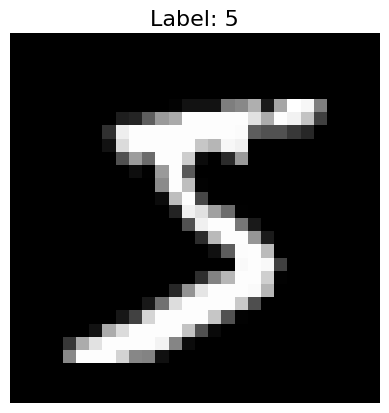

In [38]:
import load_mnist
importlib.reload(load_mnist)

def plot_mnist_image(x, y=None, index=0):
    """
    Plot a single MNIST image from flattened data.
    
    Args:
        x: np.array of shape (N, 784)
        y: np.array of shape (N, 10) or (N,) (optional, for labels)
        index: which sample to plot
    """
    img = x[index].reshape(28, 28)  # reshape flattened image
    plt.imshow(img, cmap='gray')
    
    if y is not None:
        # If one-hot, convert to integer label
        if len(y.shape) == 2:
            label = np.argmax(y[index])
        else:
            label = y[index]
        plt.title(f"Label: {label}", fontsize=16)
    
    plt.axis('off')
    plt.show()


x_train, y_train, x_test, y_test = load_mnist.load_mnist_numpy()

# Plot the first image in training set
plot_mnist_image(x_train, y_train, index=0)

### Simple Evaluation Script

This will just compute how our model is doing on the testing dataset!

In [39]:
def evaluate(model, x_test, y_test, batch_size=1000):
    correct = 0 # number correct
    total = 0 # total samples

    ### Loop through batches
    for i in range(0, len(x_test), batch_size):
        batch_x = x_test[i:i+batch_size]
        batch_y = y_test[i:i+batch_size]

        ### Inference with model
        x_tensor = Tensor(batch_x)
        logits = model.forward(x_tensor)

        ### Get the max logit (as that is our prediction)
        pred_labels = np.argmax(logits.array, axis=1)

        ### Compute how many we got correct (matches label)
        correct += np.sum(pred_labels == batch_y)

        ### Iterate total samples
        total += len(batch_y)

    return 100 * correct / total


### Training Script

We provide the majority of the training script. You simply need to fill in the SGD update rule!

In [40]:
def train(model, 
          x_train, 
          y_train, 
          x_test, 
          y_test, 
          epochs, 
          batch_size, 
          lr):
    """
    Train a model using SGD and track training & validation loss.

    Returns:
        history: dict with keys 'train_loss' and 'val_loss'
    """
    n_samples = x_train.shape[0]
    optimizer = SGD(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": []
    }
    
    for epoch in range(epochs):
        
        # Shuffle training data for every epoch
        indices = np.random.permutation(n_samples)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train[indices]

        ### Store the training loss for entire epoch so we can compute avg epoch performance
        total_train_loss = 0
        num_batches = 0

        for i in range(0, n_samples, batch_size):

            ### Grab a batch of data
            batch_x = x_train_shuffled[i:i+batch_size]
            batch_y = y_train_shuffled[i:i+batch_size]

            ### Convert to Tensor
            x_tensor = Tensor(batch_x)

            ### Pass through model
            logits = model.forward(x_tensor)

            ### Compute loss ###
            loss = cross_entropy_loss(logits, batch_y)
            
            ### Log Loss ###
            total_train_loss += loss.array
            num_batches += 1

            # Zero gradients, backward, optimizer step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        ### Logging for visuals ###
        avg_train_loss = total_train_loss / num_batches
        history["train_loss"].append(avg_train_loss)

        val_logits = model.forward(Tensor(x_test, requires_grad=False))
        val_loss = cross_entropy_loss(val_logits, y_test)
        val_loss_scalar = val_loss.array
        history["val_loss"].append(val_loss_scalar)

        test_acc = evaluate(model, x_test, y_test)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss_scalar:.4f} | Test Acc: {test_acc:.2f}%")

    return history


### Lets Train!

Now that we have everything done we can train our model! A correct implementation should get above a 95% accuracy on the test set! 

Training set: (60000, 784)
Test set: (5000, 784)

Training...
Epoch 1/5 | Train Loss: 0.3651 | Val Loss: 0.2985 | Test Acc: 90.84%
Epoch 2/5 | Train Loss: 0.1869 | Val Loss: 0.1853 | Test Acc: 94.44%
Epoch 3/5 | Train Loss: 0.1296 | Val Loss: 0.1549 | Test Acc: 95.16%
Epoch 4/5 | Train Loss: 0.0986 | Val Loss: 0.1380 | Test Acc: 95.54%
Epoch 5/5 | Train Loss: 0.0788 | Val Loss: 0.1189 | Test Acc: 96.02%

Final evaluation...
Final Test Accuracy: 96.02%


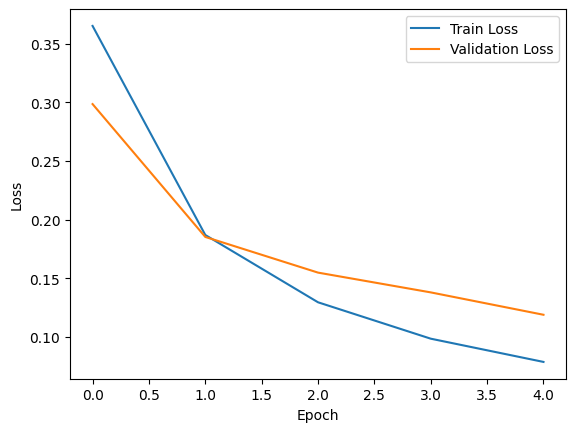

In [41]:
### SET TRAINING HYPERPARAMETERS ###
LEARNING_RATE = 0.1
BATCH_SIZE = 32
EPOCHS = 5

print(f"Training set: {x_train.shape}")
print(f"Test set: {x_test.shape}")

model = MLP(input_size=784, hidden_size=256, num_classes=10)

print("\nTraining...")
history = train(model, x_train, y_train, x_test, y_test, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE)

print("\nFinal evaluation...")
final_acc = evaluate(model, x_test, y_test)
print(f"Final Test Accuracy: {final_acc:.2f}%")

### Make a Plot of Results ###
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
